# Pipeline notebook

En este notebook estará todo el pipeline desde los datos en crudo hasta la clusterización.

## Data Preprocessing

Pre process de todos los datos, los uniremos en un unico data frame 

In [297]:
#pip install geopy

Defaulting to user installation because normal site-packages is not writeable
Note: you may need to restart the kernel to use updated packages.


In [1]:
import pandas as pd
import numpy as np
from pathlib import Path
import glob
import time
import matplotlib.pyplot as plt

In [2]:
entries_all = pd.DataFrame()

In [3]:
for excel_file in Path('C:/Users/Usuario/Desktop/Nacho/MIOTI/TFM/DATA').glob('*.xlsx'):
    conc = pd.read_excel(excel_file)
    
    entries_all = pd.concat([entries_all,conc])
    print(excel_file)

entries_all

C:\Users\Usuario\Desktop\Nacho\MIOTI\TFM\DATA\2010.xlsx
C:\Users\Usuario\Desktop\Nacho\MIOTI\TFM\DATA\2011.xlsx
C:\Users\Usuario\Desktop\Nacho\MIOTI\TFM\DATA\2012.xlsx
C:\Users\Usuario\Desktop\Nacho\MIOTI\TFM\DATA\2013.xlsx
C:\Users\Usuario\Desktop\Nacho\MIOTI\TFM\DATA\2014.xlsx
C:\Users\Usuario\Desktop\Nacho\MIOTI\TFM\DATA\2015.xlsx
C:\Users\Usuario\Desktop\Nacho\MIOTI\TFM\DATA\2016.xlsx
C:\Users\Usuario\Desktop\Nacho\MIOTI\TFM\DATA\2017.xlsx
C:\Users\Usuario\Desktop\Nacho\MIOTI\TFM\DATA\2018.xlsx
C:\Users\Usuario\Desktop\Nacho\MIOTI\TFM\DATA\2019.xlsx
C:\Users\Usuario\Desktop\Nacho\MIOTI\TFM\DATA\2020.xlsx
C:\Users\Usuario\Desktop\Nacho\MIOTI\TFM\DATA\2021.xlsx
C:\Users\Usuario\Desktop\Nacho\MIOTI\TFM\DATA\2022.xlsx


,Entrada,Fecha,Sexo,Edad,Continente,Pais,Autonomia,Medio,Motivo,Camino,Origen,Profesion
0,2010-01/0001-01,2010-01-01 00:00:00,M,58,Europa,España,Cantabria,Bicicleta,Religioso,Norte-Camino de,Resto Cantabria,Jubilados
1,2010-01/0002-01,2010-01-01 00:00:00,M,24,Europa,España,La Rioja,Pie,Religioso y otros,Frances-Camino de,Sarria,Profesores
2,2010-01/0001-02,2010-01-01 00:00:00,M,62,Europa,España,La Rioja,Pie,Religioso,Frances-Camino de,Sarria,Jubilados
3,2010-01/0002-02,2010-01-01 00:00:00,M,44,Europa,España,Murcia,Pie,Religioso,Frances-Camino de,Sarria,Agricultores
4,2010-01/0003-01,2010-01-01 00:00:00,F,64,Europa,España,La Rioja,Pie,Religioso y otros,Frances-Camino de,Sarria,Jubilados
...,...,...,...,...,...,...,...,...,...,...,...,...
437905,2022-12/21756-10,2022-12-31 16:53:44,M,55,Europa,Alemania,Residentes Extranjero,Pie,Religioso y otros,Invierno de Camino,Ponferrada. C.Inv.,NaN
437906,2022-12/21756-11,2022-12-31 17:38:37,M,47,Europa,España,Extremadura,Pie,Religioso y otros,Ingles-Camino,Ferrol,NaN
437907,2022-12/21756-12,2022-12-31 17:50:16,M,55,Europa,España,Cataluña,Pie,Religioso,Frances-Camino de,S. Jean P. Port,NaN
437908,2022-12/21756-13,2022-12-31 17:50:37,F,53,Europa,España,Cataluña,Pie,Religioso,Frances-Camino de,S. Jean P. Port,NaN


In [4]:
entries_all = entries_all.sort_values(by= 'Fecha', ascending=True)
entries_all = entries_all.sort_values(by= 'Entrada', ascending=True)
entries_all = entries_all.drop(columns='Entrada')

### Limpieza columna a columna 

### 1. Sexo

In [5]:
entries_all.Sexo.value_counts()

M    1708754
F    1579895
D          1
0          1
Name: Sexo, dtype: int64

In [6]:
entries_all = entries_all.drop(entries_all.loc[entries_all['Sexo'] == 'D'].index)
entries_all = entries_all.drop(entries_all.loc[entries_all['Sexo'] == '0'].index)
entries_all.Sexo.value_counts()

M    1708746
F    1579892
Name: Sexo, dtype: int64

### 2. Edad

<AxesSubplot:>

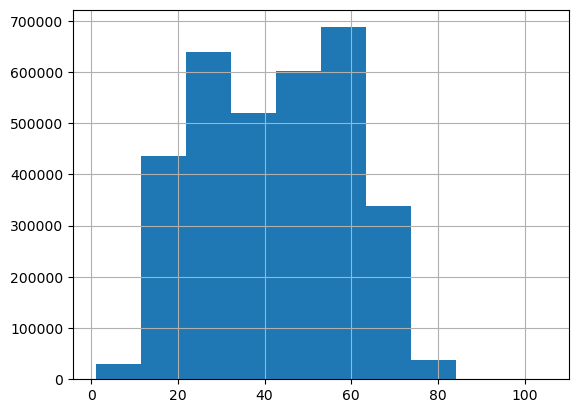

In [7]:
entries_all.Edad.hist()

In [8]:
entries_all.Edad.min()


1

In [9]:
entries_all.Edad.max()



105

 ### 3. Continente

In [10]:
entries_all[entries_all.Continente.isna()]

,Fecha,Sexo,Edad,Continente,Pais,Autonomia,Medio,Motivo,Camino,Origen,Profesion
62492,2021-08-07 18:23:31,M,29,NaN,NaN,NaN,Pie,Religioso y otros,Ingles-Camino,Ferrol,NaN


In [11]:
entries_all = entries_all.drop(entries_all.loc[entries_all['Continente'].isna()]. index)

### 4. País

In [12]:
entries_all = entries_all.drop(entries_all.loc[entries_all['Pais'].isna()]. index)

### 5. Autonomía 

In [13]:
entries_all.Autonomia.value_counts()

Andalucía                317440
Madrid                   311813
Residentes Extranjero    235366
Comunidad Valenciana     189557
Cataluña                 177802
Galicia                  143460
Castilla León             93322
Castilla la Mancha        87304
Pais Vasco                59861
Canarias                  48521
Murcia                    46560
Extremadura               46518
Aragón                    34244
Asturias                  32547
Baleares                  23534
Navarra                   16285
Cantabria                 13706
La Rioja                   7799
Ceuta                      2468
Melilla                    1544
Name: Autonomia, dtype: int64

In [14]:
mask_naaut = entries_all.Autonomia.isna()
mask_esp = entries_all['Pais'] == 'España'
entries_all[mask_naaut & mask_esp]

,Fecha,Sexo,Edad,Continente,Pais,Autonomia,Medio,Motivo,Camino,Origen,Profesion
1081,2010-01-30 00:00:00,F,27,Europa,España,NaN,Pie,Religioso,Frances-Camino de,Cebreiro,Empleados
1736,2010-02-15 00:00:00,M,28,Europa,España,NaN,Pie,No religioso,Portugues-Camino,Tui,Liberales
1737,2010-02-15 00:00:00,M,23,Europa,España,NaN,Pie,Religioso y otros,Portugues-Camino,Tui,Estudiantes
6392,2010-03-26 00:00:00,M,25,Europa,España,NaN,Pie,Religioso y otros,Frances-Camino de,Logroño,Liberales
8008,2010-03-31 00:00:00,F,17,Europa,España,NaN,Pie,Religioso y otros,Frances-Camino de,Sarria,Estudiantes
...,...,...,...,...,...,...,...,...,...,...,...
126318,2019-06-23 00:00:00,M,40,Europa,España,NaN,Pie,Religioso,Portugues-Camino,Tui,Empleados
126383,2019-06-23 00:00:00,F,40,Europa,España,NaN,Pie,Religioso y otros,Frances-Camino de,Cebreiro,Liberales
126390,2019-06-23 00:00:00,M,33,Europa,España,NaN,Pie,Religioso,Frances-Camino de,Sarria,Liberales
126431,2019-06-23 00:00:00,F,22,Europa,España,NaN,Pie,Religioso y otros,Frances-Camino de,Sarria,Estudiantes


In [15]:
mascara = mask_esp & mask_naaut
entries_all.loc[mascara, 'Autonomia'] = 'Otra'

In [16]:
mask_noesp =  entries_all['Pais'] != 'España'
mask_nonan = entries_all['Autonomia'].notna()

In [17]:
entries_all[mask_noesp & mask_nonan]

,Fecha,Sexo,Edad,Continente,Pais,Autonomia,Medio,Motivo,Camino,Origen,Profesion
3346,2010-03-10 00:00:00,F,27,América del Norte,Estados Unidos,Cataluña,Pie,Religioso y otros,Frances-Camino de,S. Jean P. Port,Liberales
3419,2010-03-11 00:00:00,M,33,Europa,Alemania,Baleares,Pie,Religioso,Frances-Camino de,León,Empleados
3429,2010-03-11 00:00:00,F,32,Oceanía,Nueva Zelanda,Castilla León,Pie,Religioso y otros,Portugues-Camino,Valença do Minho,Empleados
3634,2010-11-30 00:00:00,M,32,América del Norte,Canadá,Andalucía,Pie,Religioso,Frances-Camino de,Francia - C.F.,Profesores
3760,2010-03-14 00:00:00,F,25,América del Norte,Estados Unidos,Asturias,Pie,Religioso y otros,Frances-Camino de,León,Liberales
...,...,...,...,...,...,...,...,...,...,...,...
437893,2022-12-31 16:45:23,M,56,Europa,Portugal,Residentes Extranjero,Bicicleta,Religioso y otros,Portugues-Camino,Lisboa,NaN
437894,2022-12-31 16:45:23,M,55,Europa,Portugal,Residentes Extranjero,Bicicleta,Religioso y otros,Portugues-Camino,Lisboa,NaN
437895,2022-12-31 16:45:23,M,28,Europa,Portugal,Residentes Extranjero,Bicicleta,Religioso y otros,Portugues-Camino,Lisboa,NaN
437896,2022-12-31 16:45:23,M,16,Europa,Portugal,Residentes Extranjero,Bicicleta,Religioso y otros,Portugues-Camino,Lisboa,NaN


Estos son o Españoles residentes en el extranjero o extranjeros residentes en España.

### 6. Medio

In [18]:
entries_all[entries_all.Medio.isna()]
entries_all.Medio.value_counts()

Pie                2988069
Bicicleta           291612
Caballo               6956
Vela                  1176
Silla de ruedas        813
Name: Medio, dtype: int64

In [19]:
entries_all.loc[entries_all['Medio'] == 'Vela', 'Origen'].unique()

array(['Resto de Galicia', 'Zamora', 'Sevilla', 'S. Jean P. Port',
       'Valença do Minho', 'Roncesvalles', 'Oviedo - C.P.', 'Sarria',
       'Gijón', 'Viveiro', 'Santander', 'Resto País Vasco - C.N.',
       'Resto Asturias - C.N', 'Resto Galicia', 'Ribadeo', 'Bilbao',
       'Viana do Castelo', 'Reino Unido C.Ing', 'Francia - C.N', 'Ferrol',
       'Resto Portugal', 'Hendaya', 'Le Puy', 'Tui', 'Oporto Costa',
       'Irlanda C. Ing', 'Baiona', 'Francia - C.F.', 'Ourense',
       'Resto Cantabria', 'A Coruña', 'Povoa de Varzim', 'Logroño',
       'Holanda', 'Burgos', 'Ponferrada', 'Oporto', 'Chaves-Portugal',
       'Astorga', 'Rates, S. Pedro', 'Lisboa', 'León', 'Vigo',
       'Cataluña - O.C.', 'Muxia', 'A Guarda', 'Castilla la Mancha otros',
       'Valencia O.C.', 'Salamanca', 'C.G.A resto de Portugal',
       'Resto Andalucia', 'Lagos', 'Tavira', 'Muros', 'Porto do Son',
       'Ribadeo C. del Mar', 'Laredo', 'San Sebastián', 'Resto Europa',
       'Fazouro', 'Italia', 'Irún', 

No sabemos si se refiere ruta maritima o terrestre? 

### 7. Motivo 

In [20]:
entries_all.Motivo.unique()

array(['Religioso', 'Religioso y otros', 'No religioso'], dtype=object)

### 8. Camino

In [21]:
entries_all.loc[entries_all['Camino'] == 'Costa Camino Portugues  ', 'Camino'] = 'Costa Camino Portugues'

### 9. Origen

In [22]:
entries_all.Origen.unique()

array(['Resto Cantabria', 'Sarria', 'Ponferrada', 'Astorga', 'Braga',
       'Ourense', 'Pamplona', 'Tui', 'Lugo - C.P.', 'Roncesvalles',
       'Resto C. León C.F.', 'Laza', 'Valença do Minho', 'Cebreiro',
       'Ferrol', 'Irún', 'León', 'Holanda', 'Oporto', 'Triacastela',
       'Logroño', 'Suiza', 'Oviedo - C.P.', 'S. Jean P. Port', 'Frómista',
       'Vilafranca', 'Burgos', 'Resto Asturias - C.N', 'Francia - C.F.',
       'Sevilla', 'Castilla La Mancha VP', 'Ribadeo', 'Jaca',
       'Granja de Moreruela', 'Alemania', 'Carrión de los Condes',
       'Somport', 'Abadin', 'Resto Andalucia', 'Oviedo - C.N.', 'Vilalba',
       'Lourenzá', 'Avilés', 'Le Puy', 'Barcelona', 'Madrid - C.F.',
       'Salamanca', 'Francia - C.N', 'Sto. Domingo de la Calzada',
       'Cadavo', 'Samos', 'Zamora', 'Murcia', 'Xunqueira de Ambia',
       'Com. Valenciana - C.F.', 'Polonia', 'Lourdes', 'Cáceres',
       'Hospital de Orbigo', 'Reino Unido C.F.', 'Resto Portugal',
       'París', 'Verín', 'Santander

In [23]:
entries_all['Origen'] = [s.replace("Cast." , "Castilla") for s in entries_all.Origen]
entries_all['Origen'] = [s.replace("Resto " , "") for s in entries_all.Origen]
entries_all['Origen'] = [s.replace(" - C.F." , "") for s in entries_all.Origen]
entries_all['Origen'] = [s.replace(" - V.P." , "") for s in entries_all.Origen]
entries_all['Origen'] = [s.replace(" - C.N" , "") for s in entries_all.Origen]
entries_all['Origen'] = [s.replace(" - C.P." , "") for s in entries_all.Origen]
entries_all['Origen'] = [s.replace(" Com." , "Comunidad") for s in entries_all.Origen]
entries_all['Origen'] = [s.replace(" C.G.A." , "") for s in entries_all.Origen]
entries_all['Origen'] = [s.replace(" C.G.R." , "") for s in entries_all.Origen]
entries_all['Origen'] = [s.replace(" C.M.A." , "") for s in entries_all.Origen]
entries_all['Origen'] = [s.replace("(por Pobra de Burón)" , "") for s in entries_all.Origen]
entries_all['Origen'] = [s.replace(" (por San Xoán de Padrón )" , "") for s in entries_all.Origen]
entries_all['Origen'] = [s.replace(" (por Samos)" , "") for s in entries_all.Origen]
entries_all['Origen'] = [s.replace(" (por San XII)" , "") for s in entries_all.Origen]
entries_all['Origen'] = [s.replace("C. León C.F." , "Castilla León") for s in entries_all.Origen]
entries_all['Origen'] = [s.replace(" - O.C." , "") for s in entries_all.Origen]
entries_all['Origen'] = [s.replace(" C. Ing" , "") for s in entries_all.Origen]
entries_all['Origen'] = [s.replace(" C.Ing" , "") for s in entries_all.Origen]
entries_all['Origen'] = [s.replace("La Mesa" , "La Mesa, España") for s in entries_all.Origen]
entries_all['Origen'] = [s.replace("Hospital, España de Orbigo" , "Hospital, España") for s in entries_all.Origen]
entries_all['Origen'] = [s.replace(" C.F." , "") for s in entries_all.Origen]
entries_all['Origen'] = [s.replace(" C.Inv." , "") for s in entries_all.Origen]
entries_all['Origen'] = [s.replace(" V.P." , "") for s in entries_all.Origen]
entries_all['Origen'] = [s.replace("C.G.A. resto de " , "") for s in entries_all.Origen]
entries_all['Origen'] = [s.replace("C.G.R." , "") for s in entries_all.Origen]
entries_all['Origen'] = [s.replace("C.G.A." , "") for s in entries_all.Origen]
entries_all['Origen'] = [s.replace("O.C." , "") for s in entries_all.Origen]
entries_all['Origen'] = [s.replace("C.G.A" , "") for s in entries_all.Origen]
entries_all['Origen'] = [s.replace("C.G.R" , "") for s in entries_all.Origen]
entries_all['Origen'] = [s.replace("de Portugal C.M.R." , "Portugal") for s in entries_all.Origen]
entries_all['Origen'] = [s.replace("R.Pais Vasco" , "Pais Vasco") for s in entries_all.Origen]
entries_all['Origen'] = [s.replace("otros" , "") for s in entries_all.Origen]
entries_all['Origen'] = [s.replace("R. Castilla León C.Inv" , "Reino de Castilla y León") for s in entries_all.Origen]
entries_all['Origen'] = [s.replace("de Extremadura" , "Extremadura") for s in entries_all.Origen]
entries_all['Origen'] = [s.replace("de Portugal" , "Portugal") for s in entries_all.Origen]
entries_all['Origen'] = [s.replace("La caridad" , "La caridad, España") for s in entries_all.Origen]
entries_all['Origen'] = [s.replace(" resto " , "") for s in entries_all.Origen]
entries_all['Origen'] = [s.replace(" (por Tui)" , "") for s in entries_all.Origen]
entries_all['Origen'] = [s.replace("Vilanova de Cerveira" , "Gondarém") for s in entries_all.Origen]

entries_all['Origen'] = [s.replace("Cadavelo" , "Cadavéu") for s in entries_all.Origen]

entries_all['Origen'] = [s.replace("Santa María de Gondar" , "Gondar, Portugal") for s in entries_all.Origen]

entries_all['Origen'] = [s.replace("Santa Marta de Tara" , "Santa Marta de Tera") for s in entries_all.Origen]

entries_all['Origen'] = [s.replace("Santiago da ria de abres" , "A ria de abres") for s in entries_all.Origen]





#### Añadimos Latitud y Longitud

In [24]:
from geopy.geocoders import Nominatim
loc = Nominatim(user_agent="GetLoc")
 
# entering the location name
getLoc = loc.geocode("La Mesa, España")
 
# printing address
print(getLoc.address)
 
# printing latitude and longitude
print("Latitude = ", getLoc.latitude)
print("Longitude = ", getLoc.longitude)

La Mesa, Cazorla, Jaén, Andalucía, España
Latitude =  37.8200123
Longitude =  -2.8549504


In [25]:
cache = {}
cache2 = {}

In [26]:
loc = Nominatim(user_agent="GetLoc")



In [27]:
def latitude(texto):
    if texto in cache:
        return cache[texto]
    
    try: 
        # ingresar el nombre de la ubicación
        getLoc = loc.geocode(texto)
        if getLoc is not None:
            latitud = getLoc.latitude
            cache[texto] = latitud
            return latitud
        else:
            return None
    except:
        return None
  

In [28]:
def longitud(texto):
    if texto in cache2:
        return cache2[texto]
    
    try: 
        # ingresar el nombre de la ubicación
        getLoc = loc.geocode(texto)
        if getLoc is not None:
            longitude = getLoc.longitude
            cache2[texto] = longitude
            return longitude
        else:
            return None
    except:
        return None

In [29]:
unique_vals = entries_all['Origen'].unique()
vals = unique_vals[entries_all['Origen'].value_counts() > 9999]

print(vals)

['Cantabria' 'Sarria' 'Ponferrada' 'Astorga' 'Braga' 'Ourense' 'Pamplona'
 'Tui' 'Lugo' 'Roncesvalles' 'Castilla León' 'Laza' 'Valença do Minho'
 'Cebreiro' 'Ferrol' 'Irún' 'León' 'Holanda' 'Oporto' 'Triacastela'
 'Logroño' 'Suiza' 'Oviedo' 'S. Jean P. Port' 'Frómista' 'Vilafranca'
 'Burgos' 'Asturias' 'Francia' 'Sevilla' 'Castilla La Mancha VP' 'Ribadeo'
 'Jaca' 'Granja de Moreruela' 'Alemania' 'Carrión de los Condes' 'Somport'
 'Abadin']


In [30]:
inicio = time.time()
for ele in unique_vals:
    latitude(ele)
    longitud(ele)
fin = time.time()
print(fin-inicio)

574.5862922668457


In [31]:
len(cache)

473

In [32]:
def add_coords_to_dataframe(df, lat_dict, long_dict):
    df['Latitud'] = df['Origen'].map(lat_dict)
    df['Longitud'] = df['Origen'].map(long_dict)
    return df


In [33]:
entries_all = add_coords_to_dataframe(entries_all, cache, cache2)


In [34]:
limpeza = entries_all.loc[entries_all['Latitud'].isna(), 'Origen'].unique()
limpeza

array(['Castilla La Mancha VP', 'Rates, S. Pedro', 'Laguna de Castilla',
       'Alto do Acevo ', 'La Casquita', 'Alto do Acevo'], dtype=object)

In [35]:
entries_all[entries_all['Latitud'].isna()]

,Fecha,Sexo,Edad,Continente,Pais,Autonomia,Medio,Motivo,Camino,Origen,Profesion,Latitud,Longitud
184,2010-01-04 00:00:00,M,46,Europa,Austria,NaN,Pie,Religioso y otros,Via de la Plata,Castilla La Mancha VP,Parados,NaN,-2.160607
2598,2010-02-26 00:00:00,M,32,Europa,España,Castilla la Mancha,Bicicleta,Religioso,Via de la Plata,Castilla La Mancha VP,Tecnicos,NaN,-2.160607
2600,2010-02-26 00:00:00,M,29,Europa,España,Castilla la Mancha,Bicicleta,Religioso,Via de la Plata,Castilla La Mancha VP,Tecnicos,NaN,-2.160607
9805,2010-04-02 00:00:00,M,48,Europa,España,Castilla la Mancha,Pie,Religioso,Via de la Plata,Castilla La Mancha VP,Liberales,NaN,-2.160607
9803,2010-04-02 00:00:00,M,22,Europa,España,Castilla la Mancha,Bicicleta,Religioso y otros,Via de la Plata,Castilla La Mancha VP,Obreros,NaN,-2.160607
...,...,...,...,...,...,...,...,...,...,...,...,...,...
428961,2022-11-13 14:44:06,M,30,Europa,Portugal,Residentes Extranjero,Bicicleta,Religioso y otros,Portugues-Camino,"Rates, S. Pedro",NaN,NaN,NaN
435377,2022-12-09 16:52:51,M,34,Europa,Portugal,Residentes Extranjero,Bicicleta,Religioso y otros,Portugues-Camino,"Rates, S. Pedro",NaN,NaN,NaN
435379,2022-12-09 16:52:52,M,40,Europa,Portugal,Residentes Extranjero,Bicicleta,Religioso y otros,Portugues-Camino,"Rates, S. Pedro",NaN,NaN,NaN
435380,2022-12-09 16:52:52,M,41,Europa,Portugal,Residentes Extranjero,Bicicleta,Religioso y otros,Portugues-Camino,"Rates, S. Pedro",NaN,NaN,NaN


In [36]:
entries_all = entries_all.drop(entries_all.loc[entries_all['Latitud'].isna()]. index)

In [37]:
entries_all[entries_all['Longitud'].isna()]

,Fecha,Sexo,Edad,Continente,Pais,Autonomia,Medio,Motivo,Camino,Origen,Profesion,Latitud,Longitud


In [38]:
entries_all = entries_all.drop(entries_all.loc[entries_all['Longitud'].isna()]. index)

### 10. Profesion

In [39]:
entries_all.Profesion = entries_all.Profesion.fillna('Otros')

In [40]:
entries_all.Profesion.unique()

array(['Jubilados', 'Liberales', 'Tecnicos', 'Empleados', 'Profesores',
       'Estudiantes', 'Agricultores', 'Obreros', 'Funcionarios',
       'Sacerdotes', 'Amas de Casa', 'Parados', 'Directivos',
       'Religiosas/os', 'Artistas', 'Deportistas', 'Marinos', 'Otros'],
      dtype=object)

In [41]:
entries_all.reset_index(drop=True, inplace=True)

#### Hecha la limpieza
Guardamos el resultado 

In [42]:
filepath = Path('Treated_csv/entries_all.csv')  
filepath.parent.mkdir(parents=True, exist_ok=True)  
entries_all.to_csv(filepath)


## Preparamos el dataset para Clusterizar

## ESPAÑA

#### 1. Añadimos las columnas que nos parecen interesantes 

In [43]:
spain = entries_all.copy()

In [44]:
spain.head()

,Fecha,Sexo,Edad,Continente,Pais,Autonomia,Medio,Motivo,Camino,Origen,Profesion,Latitud,Longitud
0,2010-01-01,M,58,Europa,España,Cantabria,Bicicleta,Religioso,Norte-Camino de,Cantabria,Jubilados,43.159566,-4.087838
1,2010-01-01,M,62,Europa,España,La Rioja,Pie,Religioso,Frances-Camino de,Sarria,Jubilados,42.778420,-7.414661
2,2010-01-01,M,54,Europa,España,Comunidad Valenciana,Pie,Religioso,Frances-Camino de,Ponferrada,Liberales,42.545412,-6.593872
3,2010-01-01,F,44,Europa,España,Comunidad Valenciana,Pie,Religioso,Frances-Camino de,Ponferrada,Tecnicos,42.545412,-6.593872
4,2010-01-01,F,64,Europa,Alemania,NaN,Pie,Religioso,Frances-Camino de,Astorga,Empleados,42.455356,-6.052903


In [45]:
spain = spain[spain['Pais'] == 'España']

In [46]:
spain = spain.drop(spain[spain['Pais'] != 'España'].index)

In [47]:
spain_2 = entries_all.copy()

In [48]:
spain_2 = spain_2[spain_2['Pais'] == 'España']

In [49]:
spain_2 = spain_2.drop(spain_2[spain_2['Pais'] != 'España'].index)

In [50]:
spain['Mes'] = spain['Fecha'].dt.month
spain['Dia'] = pd.to_datetime(spain['Fecha']).dt.day_name()
spain.head()

,Fecha,Sexo,Edad,Continente,Pais,Autonomia,Medio,Motivo,Camino,Origen,Profesion,Latitud,Longitud,Mes,Dia
0,2010-01-01,M,58,Europa,España,Cantabria,Bicicleta,Religioso,Norte-Camino de,Cantabria,Jubilados,43.159566,-4.087838,1,Friday
1,2010-01-01,M,62,Europa,España,La Rioja,Pie,Religioso,Frances-Camino de,Sarria,Jubilados,42.778420,-7.414661,1,Friday
2,2010-01-01,M,54,Europa,España,Comunidad Valenciana,Pie,Religioso,Frances-Camino de,Ponferrada,Liberales,42.545412,-6.593872,1,Friday
3,2010-01-01,F,44,Europa,España,Comunidad Valenciana,Pie,Religioso,Frances-Camino de,Ponferrada,Tecnicos,42.545412,-6.593872,1,Friday
8,2010-01-01,M,43,Europa,España,Castilla la Mancha,Pie,Religioso,Frances-Camino de,Sarria,Empleados,42.778420,-7.414661,1,Friday


In [51]:
spain_2['Mes'] = spain_2['Fecha'].dt.month
spain_2['Dia'] = pd.to_datetime(spain_2['Fecha']).dt.day_name()
spain_2.head()

,Fecha,Sexo,Edad,Continente,Pais,Autonomia,Medio,Motivo,Camino,Origen,Profesion,Latitud,Longitud,Mes,Dia
0,2010-01-01,M,58,Europa,España,Cantabria,Bicicleta,Religioso,Norte-Camino de,Cantabria,Jubilados,43.159566,-4.087838,1,Friday
1,2010-01-01,M,62,Europa,España,La Rioja,Pie,Religioso,Frances-Camino de,Sarria,Jubilados,42.778420,-7.414661,1,Friday
2,2010-01-01,M,54,Europa,España,Comunidad Valenciana,Pie,Religioso,Frances-Camino de,Ponferrada,Liberales,42.545412,-6.593872,1,Friday
3,2010-01-01,F,44,Europa,España,Comunidad Valenciana,Pie,Religioso,Frances-Camino de,Ponferrada,Tecnicos,42.545412,-6.593872,1,Friday
8,2010-01-01,M,43,Europa,España,Castilla la Mancha,Pie,Religioso,Frances-Camino de,Sarria,Empleados,42.778420,-7.414661,1,Friday


#### 2. Eliminamos las columnas con las que no trabajaremos

In [52]:
spain = spain.drop(["Fecha", "Pais", "Continente", "Medio", "Motivo", "Origen"], axis=1)

#### 3. Convertimos variables categoricas en numericas



#### 3.1 Dummies

In [53]:
def do_onehot_encoding(df, cols):
    df = pd.get_dummies(df, columns=cols)
    return df


def undo_onehot_encoding(df, cols):
    for col in cols:
        prefix = col + '_'
        cat_cols = [c for c in df.columns if c.startswith(prefix)]
        col_values = df[cat_cols].idxmax(axis=1).apply(lambda x: x.split(prefix)[-1])
        df[col] = col_values
        df.drop(cat_cols, axis=1, inplace=True)
    return df

In [54]:
spain = do_onehot_encoding(spain, ["Sexo", "Autonomia", "Camino", "Profesion", "Dia"])


#### 3.2 Count Encoding 

In [55]:
def count_encoding(df, cols):
    for col in cols:
        col_count = df[col].value_counts().to_dict()
        df[col+'_count'] = df[col].map(col_count)
    return df

def undo_count_encoding(df, cols):
    for col in cols:
        col_name = col.split('_count')[0]
        col_dict = df.groupby(col_name)[col].mean().to_dict()
        df[col_name] = df[col].map(col_dict)
        df.drop(col, axis=1, inplace=True)
    return df


#### 4. Escalamos las variables

In [56]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

def escala_col(df, cols):
    df[cols] = scaler.fit_transform(df[cols])
    
    return df

def desescala_col(df, cols, scaler):
    df[cols] = scaler.inverse_transform(df[cols])
    
    return df

In [57]:
spain = escala_col(spain, ['Edad', 'Longitud', 'Latitud', 'Mes'])

## Clusterizamos

In [58]:
from sklearn.cluster import KMeans


In [59]:
distortions = []                                                  
K = range(2, 10)                                                  

for k in K:
    kmeanModel = KMeans(n_clusters=k,random_state=42)              
    kmeanModel.fit(spain)                                    
    distortions.append(kmeanModel.inertia_)    

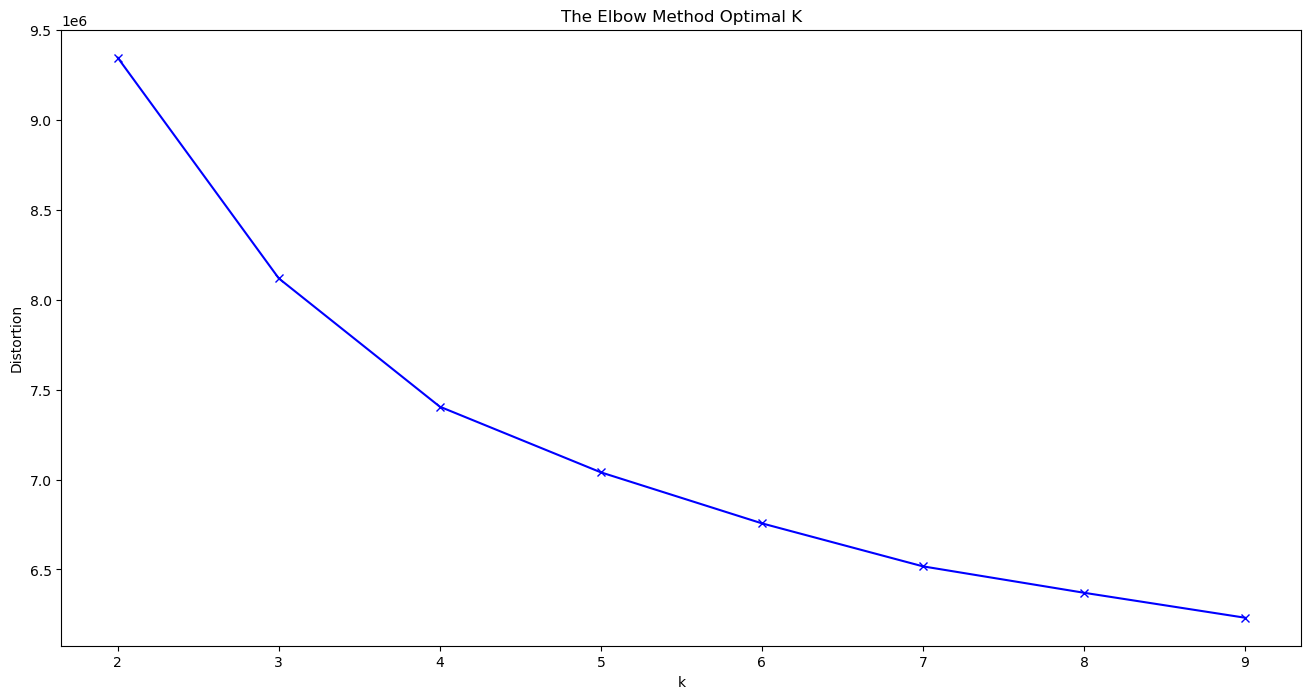

In [60]:
# Let's plot the the elbow plot

plt.figure(figsize=(16, 8))                                           

plt.plot(K, distortions, "bx-")                                       

plt.xlabel("k")                                                      

plt.ylabel("Distortion")                                            

plt.title("The Elbow Method Optimal K")                   
plt.show()

In [61]:
kmeans = KMeans(n_clusters =4, random_state = 42)
kmeans.fit(spain)

labels = kmeans.labels_


In [62]:
len(labels)


1641941

In [63]:
spain_2['Cluster'] = labels
spain['Cluster'] = labels


## Visualizamos

In [64]:
def histxvar(df,col):

    for i in range(4):
        plt.hist(df.loc[df['Cluster'] == i, col], alpha=0.5, label='Cluster {}'.format(i))
    plt.legend()
    plt.show()

In [65]:
spain_2.head()

,Fecha,Sexo,Edad,Continente,Pais,Autonomia,Medio,Motivo,Camino,Origen,Profesion,Latitud,Longitud,Mes,Dia,Cluster
0,2010-01-01,M,58,Europa,España,Cantabria,Bicicleta,Religioso,Norte-Camino de,Cantabria,Jubilados,43.159566,-4.087838,1,Friday,1
1,2010-01-01,M,62,Europa,España,La Rioja,Pie,Religioso,Frances-Camino de,Sarria,Jubilados,42.778420,-7.414661,1,Friday,1
2,2010-01-01,M,54,Europa,España,Comunidad Valenciana,Pie,Religioso,Frances-Camino de,Ponferrada,Liberales,42.545412,-6.593872,1,Friday,1
3,2010-01-01,F,44,Europa,España,Comunidad Valenciana,Pie,Religioso,Frances-Camino de,Ponferrada,Tecnicos,42.545412,-6.593872,1,Friday,1
8,2010-01-01,M,43,Europa,España,Castilla la Mancha,Pie,Religioso,Frances-Camino de,Sarria,Empleados,42.778420,-7.414661,1,Friday,1


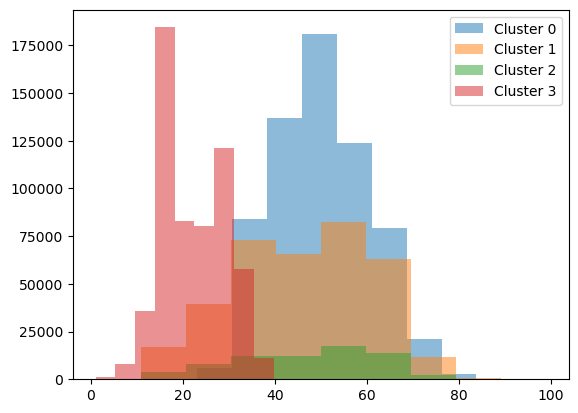

In [66]:
histxvar(spain_2,'Edad')

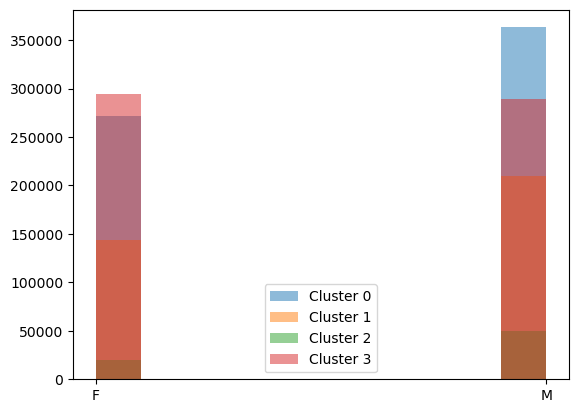

In [67]:
histxvar(spain_2,'Sexo')

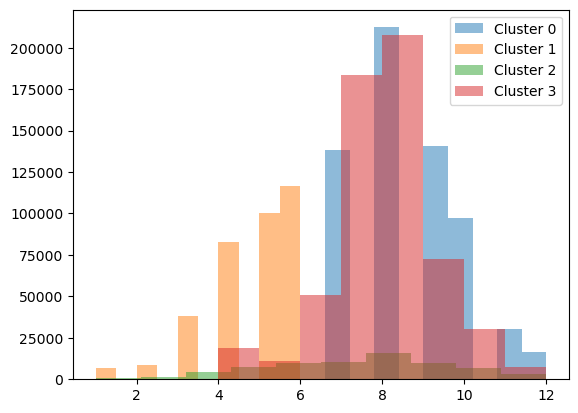

In [68]:
histxvar(spain_2,'Mes')

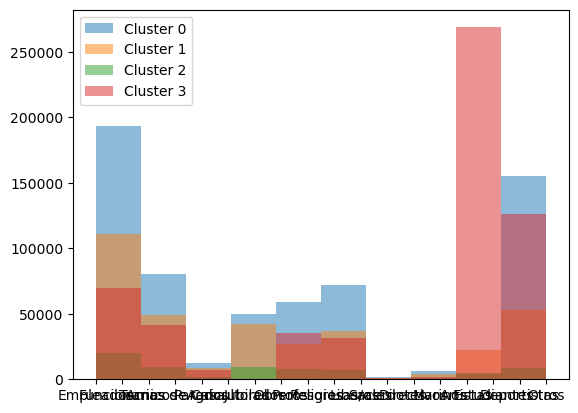

In [69]:
histxvar(spain_2, 'Profesion')

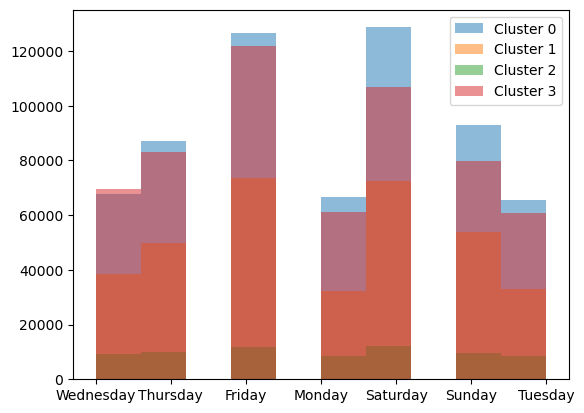

In [70]:
histxvar(spain_2, 'Dia')

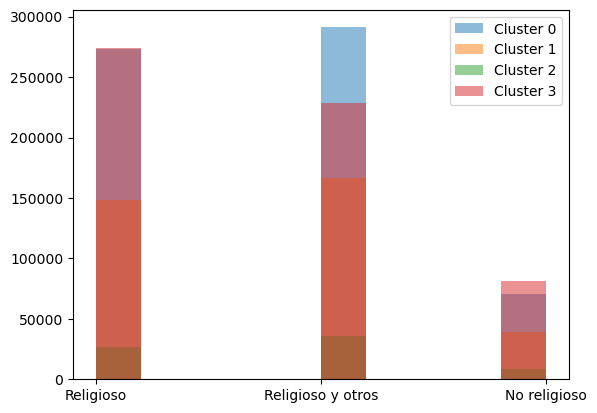

In [71]:
histxvar(spain_2, 'Motivo')

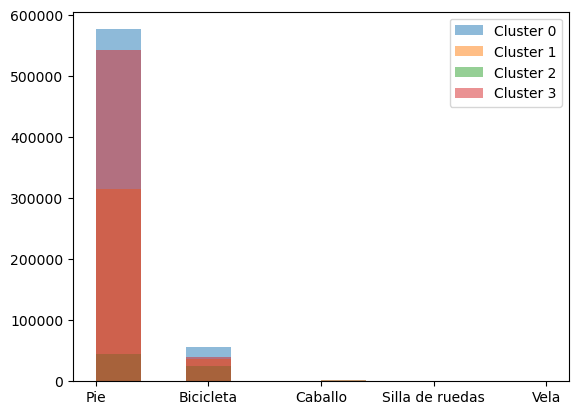

In [72]:
histxvar(spain_2, 'Medio')

## EDA Clusters

## 1. Análisis General

In [214]:
spain_2.info()

<class 'pandas.core.frame.DataFrame'>
Int64Index: 1641941 entries, 0 to 3232533
Data columns (total 16 columns):
 #   Column      Non-Null Count    Dtype         
---  ------      --------------    -----         
 0   Fecha       1641941 non-null  datetime64[ns]
 1   Sexo        1641941 non-null  object        
 2   Edad        1641941 non-null  int64         
 3   Continente  1641941 non-null  object        
 4   Pais        1641941 non-null  object        
 5   Autonomia   1641941 non-null  object        
 6   Medio       1641941 non-null  object        
 7   Motivo      1641941 non-null  object        
 8   Camino      1641941 non-null  object        
 9   Origen      1641941 non-null  object        
 10  Profesion   1641941 non-null  object        
 11  Latitud     1641941 non-null  float64       
 12  Longitud    1641941 non-null  float64       
 13  Mes         1641941 non-null  int64         
 14  Dia         1641941 non-null  object        
 15  Cluster     1641941 non-null  in

In [208]:
cluster_counts = spain_2['Cluster'].value_counts()
cluster_percentages = cluster_counts / cluster_counts.sum() * 100
print(cluster_percentages)

0    38.684825
3    35.520582
1    21.533600
2     4.260994
Name: Cluster, dtype: float64


In [209]:
peregrinos_cluster_0 = len(spain_2[spain_2['Cluster'] == 0])
peregrinos_cluster_1 = len(spain_2[spain_2['Cluster'] == 1])
peregrinos_cluster_2 = len(spain_2[spain_2['Cluster'] == 2])
peregrinos_cluster_3 = len(spain_2[spain_2['Cluster'] == 3])
print ('Cantidad de peregrinos en el Cluster 0 = ', peregrinos_cluster_0, "\nCantidad de peregrinos en el Cluster 1 = ",peregrinos_cluster_1, "\nCantidad de peregrinos en el Cluster 2 = ",peregrinos_cluster_2, "\nCantidad de peregrinos en el Cluster 3 = ",peregrinos_cluster_3)

Cantidad de peregrinos en el Cluster 0 =  635182 
Cantidad de peregrinos en el Cluster 1 =  353569 
Cantidad de peregrinos en el Cluster 2 =  69963 
Cantidad de peregrinos en el Cluster 3 =  583227


C:\Users\Usuario\AppData\Local\Temp\ipykernel_13956\3405470116.py:25: UserWarning: FixedFormatter should only be used together with FixedLocator
  axs[row, col].set_xticklabels(data_cluster.unique(), rotation=0)


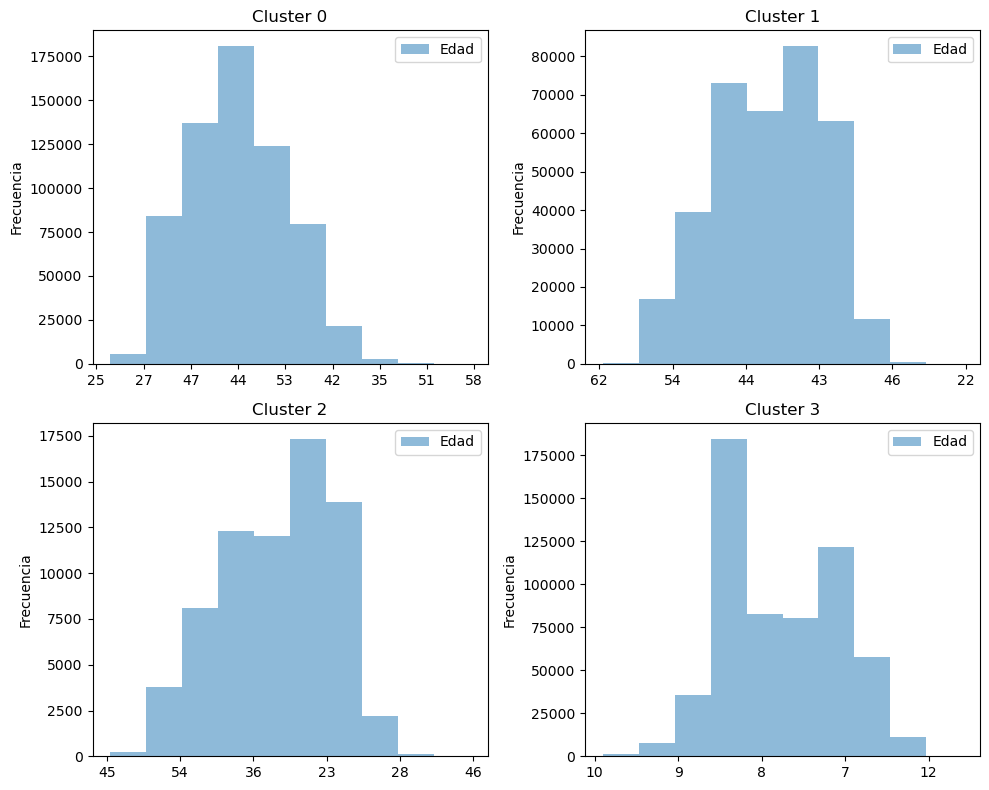

In [290]:
import matplotlib.pyplot as plt

def histxvar(df, col, rotation='horizontal'):
    clusters = df['Cluster'].unique()

    fig, axs = plt.subplots(2, 2, figsize=(10, 8))

    # Definir el orden deseado de los clusters
    cluster_order = [0, 1, 2, 3]

    for i, cluster in enumerate(cluster_order):
        row = i // 2
        col = i % 2

        data_cluster = df.loc[df['Cluster'] == cluster, 'Edad']

        axs[row, col].hist(data_cluster, alpha=0.5, label='Edad')
        axs[row, col].set_title('Cluster {}'.format(cluster))
        #axs[row, col].set_xlabel('Edad')
        axs[row, col].set_ylabel('Frecuencia')

        if rotation == 'vertical':
            axs[row, col].set_xticklabels(data_cluster.unique(), rotation=90)
        elif rotation == 'horizontal':
            axs[row, col].set_xticklabels(data_cluster.unique(), rotation=0)

        axs[row, col].legend()

    plt.tight_layout()
    plt.show()


histxvar(spain_2, 'Edad', rotation='horizontal')

C:\Users\Usuario\AppData\Local\Temp\ipykernel_13956\2133333962.py:23: UserWarning: FixedFormatter should only be used together with FixedLocator
  axs[row, col].set_xticklabels(data_cluster.unique(), rotation=0)
C:\Users\Usuario\AppData\Local\Temp\ipykernel_13956\2133333962.py:23: UserWarning: FixedFormatter should only be used together with FixedLocator
  axs[row, col].set_xticklabels(data_cluster.unique(), rotation=0)
C:\Users\Usuario\AppData\Local\Temp\ipykernel_13956\2133333962.py:23: UserWarning: FixedFormatter should only be used together with FixedLocator
  axs[row, col].set_xticklabels(data_cluster.unique(), rotation=0)
C:\Users\Usuario\AppData\Local\Temp\ipykernel_13956\2133333962.py:23: UserWarning: FixedFormatter should only be used together with FixedLocator
  axs[row, col].set_xticklabels(data_cluster.unique(), rotation=0)


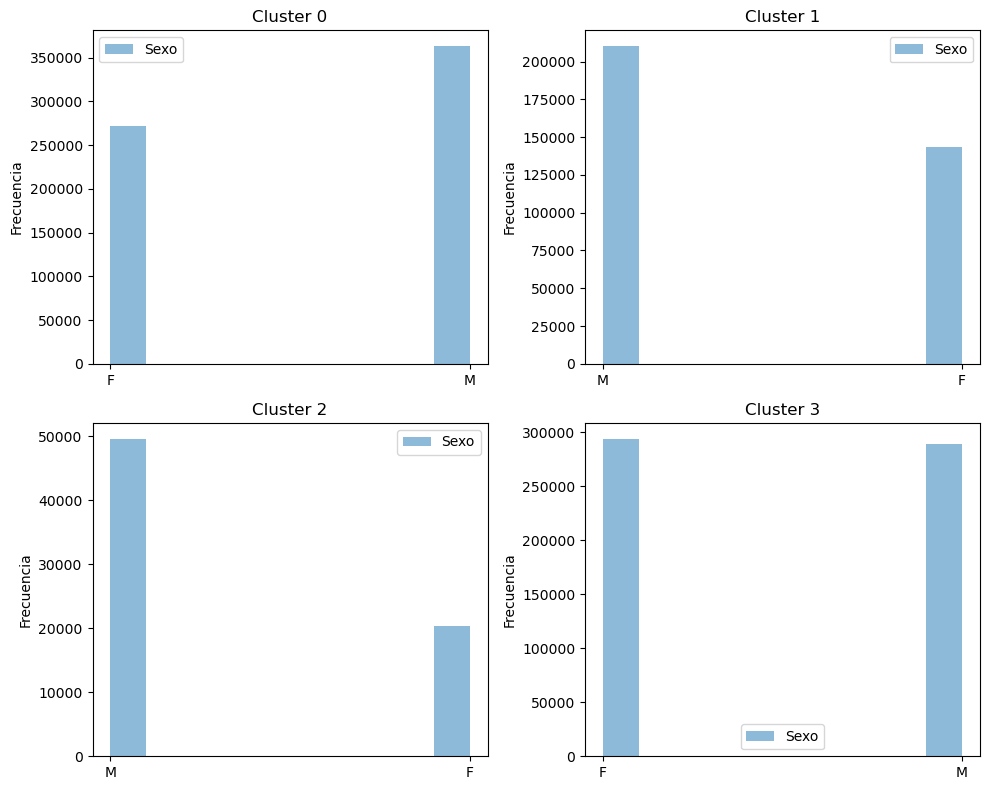

In [291]:

def histxvar(df, col, rotation='horizontal'):
    clusters = df['Cluster'].unique()

    fig, axs = plt.subplots(2, 2, figsize=(10, 8))

    # Definir el orden deseado de los clusters
    cluster_order = [0, 1, 2, 3]

    for i, cluster in enumerate(cluster_order):
        row = i // 2
        col = i % 2

        data_cluster = df.loc[df['Cluster'] == cluster, 'Sexo']

        axs[row, col].hist(data_cluster, alpha=0.5, label='Sexo')
        axs[row, col].set_title('Cluster {}'.format(cluster))
        #axs[row, col].set_xlabel('Edad')
        axs[row, col].set_ylabel('Frecuencia')

        if rotation == 'vertical':
            axs[row, col].set_xticklabels(data_cluster.unique(), rotation=90)
        elif rotation == 'horizontal':
            axs[row, col].set_xticklabels(data_cluster.unique(), rotation=0)

        axs[row, col].legend()

    plt.tight_layout()
    plt.show()


histxvar(spain_2, 'Sexo', rotation='horizontal')

C:\Users\Usuario\AppData\Local\Temp\ipykernel_13956\1486972910.py:20: UserWarning: FixedFormatter should only be used together with FixedLocator
  axs[row, col].set_xticklabels(data_cluster.unique(), rotation=90)
C:\Users\Usuario\AppData\Local\Temp\ipykernel_13956\1486972910.py:20: UserWarning: FixedFormatter should only be used together with FixedLocator
  axs[row, col].set_xticklabels(data_cluster.unique(), rotation=90)
C:\Users\Usuario\AppData\Local\Temp\ipykernel_13956\1486972910.py:20: UserWarning: FixedFormatter should only be used together with FixedLocator
  axs[row, col].set_xticklabels(data_cluster.unique(), rotation=90)
C:\Users\Usuario\AppData\Local\Temp\ipykernel_13956\1486972910.py:20: UserWarning: FixedFormatter should only be used together with FixedLocator
  axs[row, col].set_xticklabels(data_cluster.unique(), rotation=90)


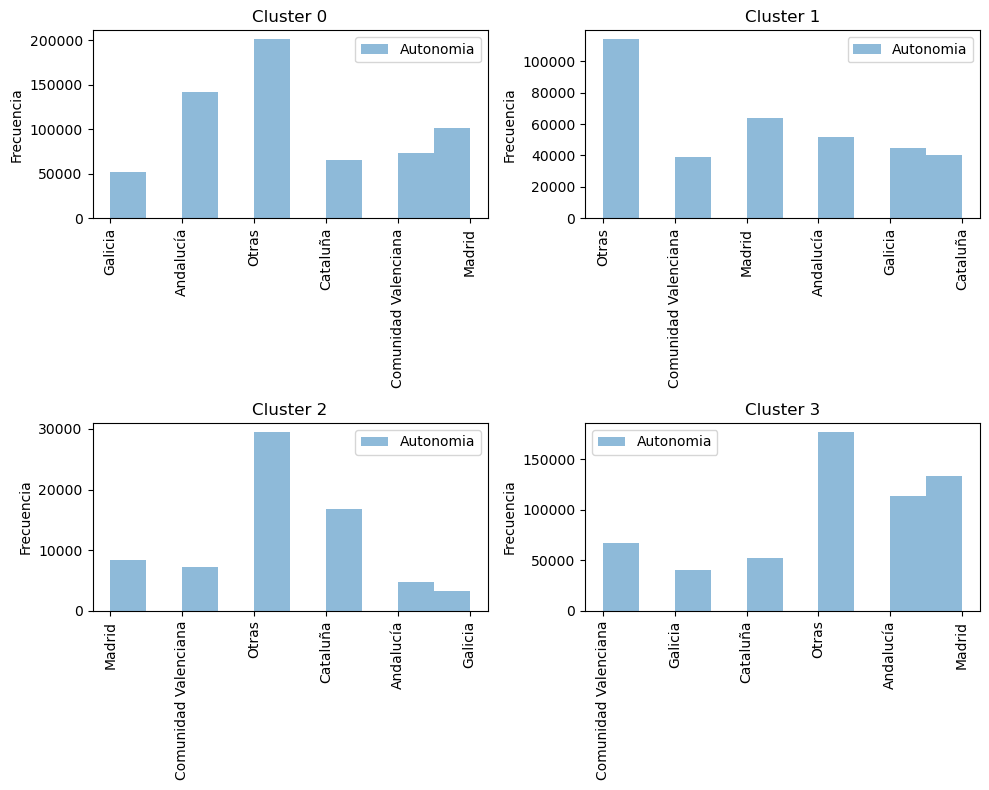

In [301]:

def histxvar(df, col, rotation='horizontal'):
    clusters = df['Cluster'].unique()

    fig, axs = plt.subplots(2, 2, figsize=(10, 8))

    # Definir el orden deseado de los clusters
    cluster_order = [0, 1, 2, 3]

    for i, cluster in enumerate(cluster_order):
        row = i // 2
        col = i % 2

        data_cluster = df.loc[df['Cluster'] == cluster, 'Autonomia']

        axs[row, col].hist(data_cluster, alpha=0.5, label='Autonomia')
        axs[row, col].set_title('Cluster {}'.format(cluster))
        axs[row, col].set_ylabel('Frecuencia')

        if rotation == 'vertical':
            axs[row, col].set_xticklabels(data_cluster.unique(), rotation=90)
        elif rotation == 'horizontal':
            axs[row, col].set_xticklabels(data_cluster.unique(), rotation=0)

        axs[row, col].legend()

    plt.tight_layout()
    plt.show()


# Reducir la columna 'Autonomia' a las 5 categorías más frecuentes
top_5_autonomias = spain_2['Autonomia'].value_counts().nlargest(5).index
spain_2.loc[~spain_2['Autonomia'].isin(top_5_autonomias), 'Autonomia'] = 'Otras'

histxvar(spain_2, 'Autonomia', rotation='vertical')


C:\Users\Usuario\AppData\Local\Temp\ipykernel_13956\1920234982.py:23: UserWarning: FixedFormatter should only be used together with FixedLocator
  axs[row, col].set_xticklabels(data_cluster.unique(), rotation=0)
C:\Users\Usuario\AppData\Local\Temp\ipykernel_13956\1920234982.py:23: UserWarning: FixedFormatter should only be used together with FixedLocator
  axs[row, col].set_xticklabels(data_cluster.unique(), rotation=0)
C:\Users\Usuario\AppData\Local\Temp\ipykernel_13956\1920234982.py:23: UserWarning: FixedFormatter should only be used together with FixedLocator
  axs[row, col].set_xticklabels(data_cluster.unique(), rotation=0)
C:\Users\Usuario\AppData\Local\Temp\ipykernel_13956\1920234982.py:23: UserWarning: FixedFormatter should only be used together with FixedLocator
  axs[row, col].set_xticklabels(data_cluster.unique(), rotation=0)


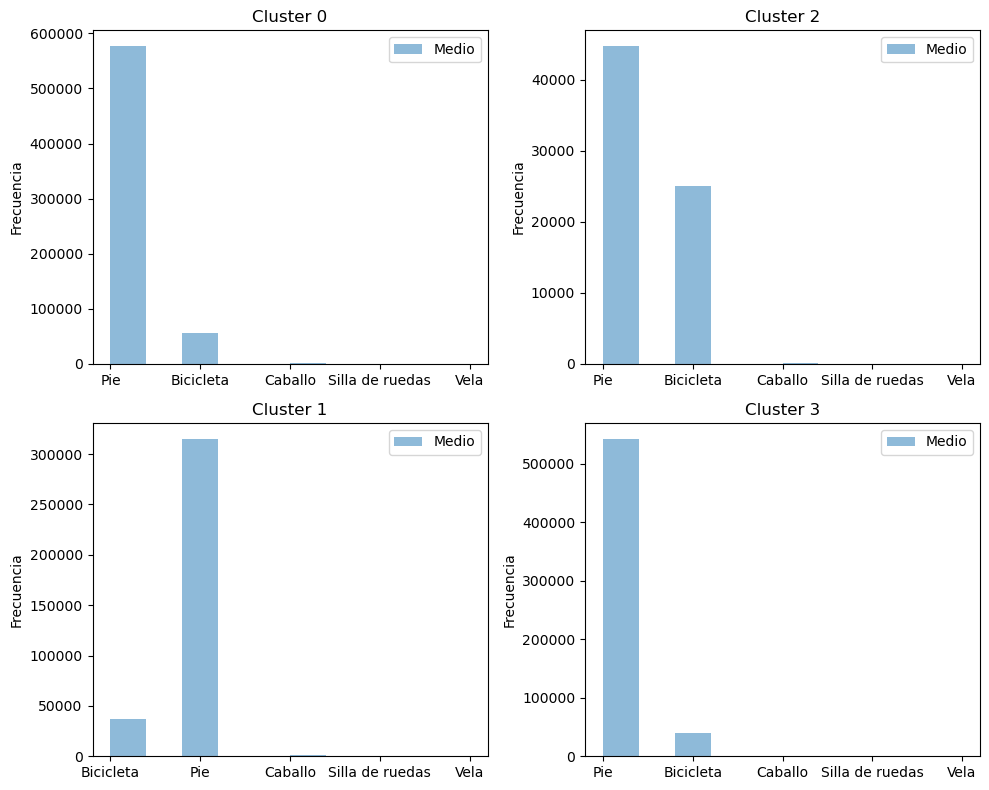

In [288]:

def histxvar(df, col, rotation='horizontal'):
    clusters = df['Cluster'].unique()

    fig, axs = plt.subplots(2, 2, figsize=(10, 8))

    # Definir el orden deseado de los clusters
    cluster_order = [0, 2, 1, 3]

    for i, cluster in enumerate(cluster_order):
        row = i // 2
        col = i % 2

        data_cluster = df.loc[df['Cluster'] == cluster, 'Medio']

        axs[row, col].hist(data_cluster, alpha=0.5, label='Medio')
        axs[row, col].set_title('Cluster {}'.format(cluster))
        #axs[row, col].set_xlabel('Edad')
        axs[row, col].set_ylabel('Frecuencia')

        if rotation == 'vertical':
            axs[row, col].set_xticklabels(data_cluster.unique(), rotation=90)
        elif rotation == 'horizontal':
            axs[row, col].set_xticklabels(data_cluster.unique(), rotation=0)

        axs[row, col].legend()

    plt.tight_layout()
    plt.show()


histxvar(spain_2, 'Medio', rotation='horizontal')

C:\Users\Usuario\AppData\Local\Temp\ipykernel_13956\4028579060.py:23: UserWarning: FixedFormatter should only be used together with FixedLocator
  axs[row, col].set_xticklabels(data_cluster.unique(), rotation=0)
C:\Users\Usuario\AppData\Local\Temp\ipykernel_13956\4028579060.py:23: UserWarning: FixedFormatter should only be used together with FixedLocator
  axs[row, col].set_xticklabels(data_cluster.unique(), rotation=0)
C:\Users\Usuario\AppData\Local\Temp\ipykernel_13956\4028579060.py:23: UserWarning: FixedFormatter should only be used together with FixedLocator
  axs[row, col].set_xticklabels(data_cluster.unique(), rotation=0)
C:\Users\Usuario\AppData\Local\Temp\ipykernel_13956\4028579060.py:23: UserWarning: FixedFormatter should only be used together with FixedLocator
  axs[row, col].set_xticklabels(data_cluster.unique(), rotation=0)


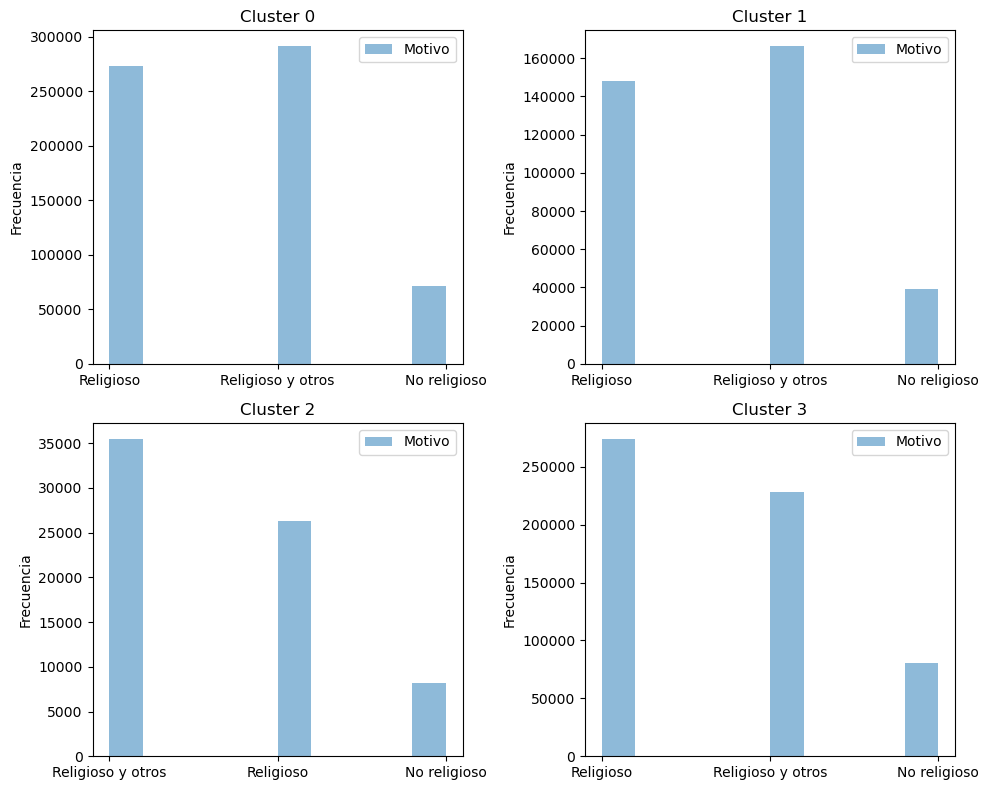

In [293]:

def histxvar(df, col, rotation='horizontal'):
    clusters = df['Cluster'].unique()

    fig, axs = plt.subplots(2, 2, figsize=(10, 8))

    # Definir el orden deseado de los clusters
    cluster_order = [0, 1, 2, 3]

    for i, cluster in enumerate(cluster_order):
        row = i // 2
        col = i % 2

        data_cluster = df.loc[df['Cluster'] == cluster, 'Motivo']

        axs[row, col].hist(data_cluster, alpha=0.5, label='Motivo')
        axs[row, col].set_title('Cluster {}'.format(cluster))
        #axs[row, col].set_xlabel('Edad')
        axs[row, col].set_ylabel('Frecuencia')

        if rotation == 'vertical':
            axs[row, col].set_xticklabels(data_cluster.unique(), rotation=90)
        elif rotation == 'horizontal':
            axs[row, col].set_xticklabels(data_cluster.unique(), rotation=0)

        axs[row, col].legend()

    plt.tight_layout()
    plt.show()


histxvar(spain_2, 'Motivo', rotation='horizontal')

C:\Users\Usuario\AppData\Local\Temp\ipykernel_13956\1430254788.py:20: UserWarning: FixedFormatter should only be used together with FixedLocator
  axs[row, col].set_xticklabels(data_cluster.unique(), rotation=90)
C:\Users\Usuario\AppData\Local\Temp\ipykernel_13956\1430254788.py:20: UserWarning: FixedFormatter should only be used together with FixedLocator
  axs[row, col].set_xticklabels(data_cluster.unique(), rotation=90)
C:\Users\Usuario\AppData\Local\Temp\ipykernel_13956\1430254788.py:20: UserWarning: FixedFormatter should only be used together with FixedLocator
  axs[row, col].set_xticklabels(data_cluster.unique(), rotation=90)
C:\Users\Usuario\AppData\Local\Temp\ipykernel_13956\1430254788.py:20: UserWarning: FixedFormatter should only be used together with FixedLocator
  axs[row, col].set_xticklabels(data_cluster.unique(), rotation=90)


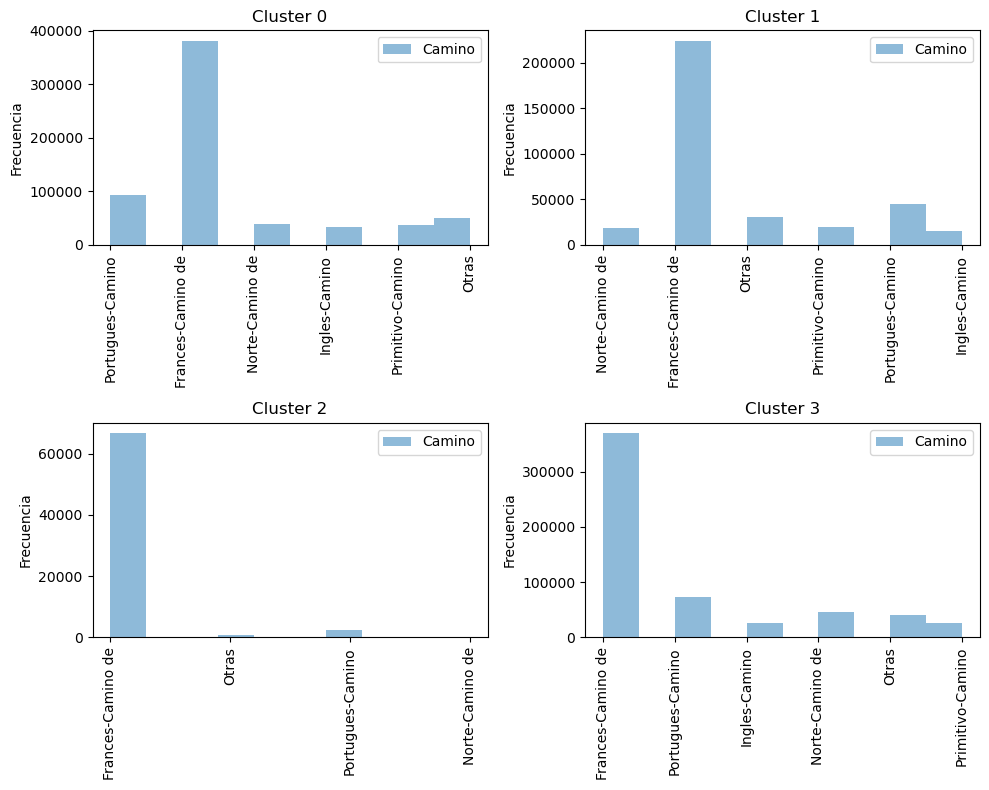

In [302]:

def histxvar(df, col, rotation='horizontal'):
    clusters = df['Cluster'].unique()

    fig, axs = plt.subplots(2, 2, figsize=(10, 8))

    # Definir el orden deseado de los clusters
    cluster_order = [0, 1, 2, 3]

    for i, cluster in enumerate(cluster_order):
        row = i // 2
        col = i % 2

        data_cluster = df.loc[df['Cluster'] == cluster, 'Camino']

        axs[row, col].hist(data_cluster, alpha=0.5, label='Camino')
        axs[row, col].set_title('Cluster {}'.format(cluster))
        axs[row, col].set_ylabel('Frecuencia')

        if rotation == 'vertical':
            axs[row, col].set_xticklabels(data_cluster.unique(), rotation=90)
        elif rotation == 'horizontal':
            axs[row, col].set_xticklabels(data_cluster.unique(), rotation=0)

        axs[row, col].legend()

    plt.tight_layout()
    plt.show()


# Reducir la columna 'Autonomia' a las 5 categorías más frecuentes
top_5_autonomias = spain_2['Camino'].value_counts().nlargest(5).index
spain_2.loc[~spain_2['Camino'].isin(top_5_autonomias), 'Camino'] = 'Otras'

histxvar(spain_2, 'Camino', rotation='vertical')


C:\Users\Usuario\AppData\Local\Temp\ipykernel_13956\3026879805.py:23: UserWarning: FixedFormatter should only be used together with FixedLocator
  axs[row, col].set_xticklabels(data_cluster.unique(), rotation=0)


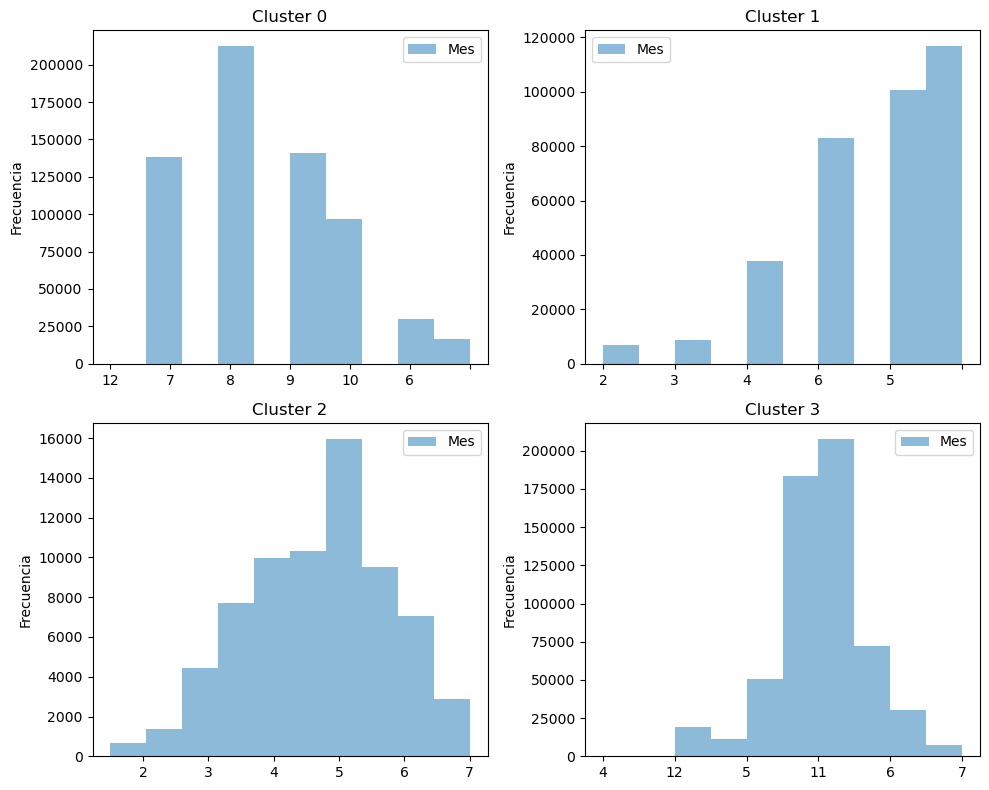

In [297]:

def histxvar(df, col, rotation='horizontal'):
    clusters = df['Cluster'].unique()

    fig, axs = plt.subplots(2, 2, figsize=(10, 8))

    # Definir el orden deseado de los clusters
    cluster_order = [0, 1, 2, 3]

    for i, cluster in enumerate(cluster_order):
        row = i // 2
        col = i % 2

        data_cluster = df.loc[df['Cluster'] == cluster, 'Mes']

        axs[row, col].hist(data_cluster, alpha=0.5, label='Mes')
        axs[row, col].set_title('Cluster {}'.format(cluster))
        #axs[row, col].set_xlabel('Edad')
        axs[row, col].set_ylabel('Frecuencia')

        if rotation == 'vertical':
            axs[row, col].set_xticklabels(data_cluster.unique(), rotation=90)
        elif rotation == 'horizontal':
            axs[row, col].set_xticklabels(data_cluster.unique(), rotation=0)

        axs[row, col].legend()

    plt.tight_layout()
    plt.show()


histxvar(spain_2, 'Mes', rotation='horizontal')

## 2. Cluster 0

In [73]:
cluster_0_spain = spain_2.loc[spain_2['Cluster'] == 0]


In [74]:
edad_0 = cluster_0_spain.Edad.mean()
round(edad_0)

50

In [75]:
sexo_0 = cluster_0_spain.Sexo.value_counts().index.tolist()
sexo_0[0]

'M'

In [76]:
autonomia_0 = cluster_0_spain.Autonomia.value_counts().index.tolist()
autonomia_0[0]

'Andalucía'

In [77]:
medio_0 = cluster_0_spain.Medio.value_counts().index.tolist()
medio_0[0]

'Pie'

In [78]:
motivo_0 = cluster_0_spain.Motivo.value_counts().index.tolist()
motivo_0[0]

'Religioso y otros'

In [79]:
camino_0 = cluster_0_spain.Camino.value_counts().index.tolist()
camino_0[0]

'Frances-Camino de'

In [80]:
origen_0 = cluster_0_spain.Origen.value_counts().index.tolist()
origen_0[0]

'Sarria'

In [81]:
profesion_0 = cluster_0_spain.Profesion.value_counts().index.tolist()
profesion_0[0]

'Otros'

In [82]:
mes_0 = cluster_0_spain.Mes.value_counts().index.tolist()
mes_0[:3]

[8, 9, 7]

In [168]:
print("El perfil del Cluster 0 hace referencia a una persona de: \n ",'Edad:',round(edad_0), 'años \n', 'Sexo:',sexo_0[0] , '\n', 'Profesión:', profesion_0[0],'\n', 'Residencia:', autonomia_0[0], '\n', 'Medio de traslado:', medio_0[0], '\n', 'Motivo:', motivo_0[0], '\n', 'Camino realizado:', camino_0[0], '\n', 'Origen:', origen_0[0], '\n', 'Mes de viaje:', mes_0[:3])

El perfil del Cluster 0 hace referencia a una persona de: 
  Edad: 50 años 
 Sexo: M 
 Profesión: Otros 
 Residencia: Andalucía 
 Medio de traslado: Pie 
 Motivo: Religioso y otros 
 Camino realizado: Frances-Camino de 
 Origen: Sarria 
 Mes de viaje: [8, 9, 7]


In [159]:
def histxvar(df, col, rotation=None):
    plt.hist(df.loc[df['Cluster'] == 0, col], alpha=0.5, label='Cluster 0')
    plt.legend()
    if rotation:
        plt.xticks(rotation=rotation)
    plt.show()

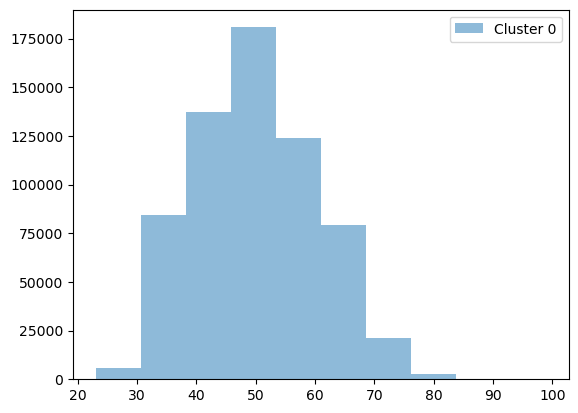

In [160]:
histxvar(spain_2, 'Edad')

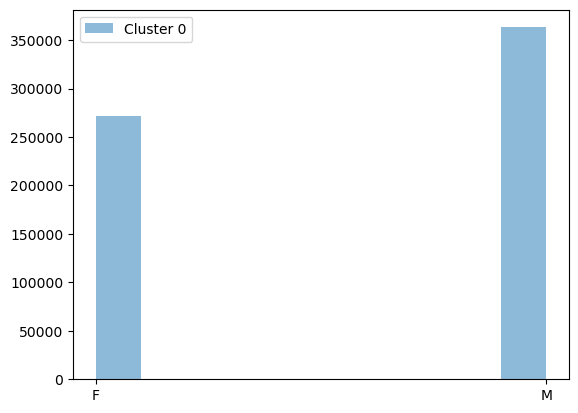

In [161]:
histxvar(spain_2, 'Sexo')

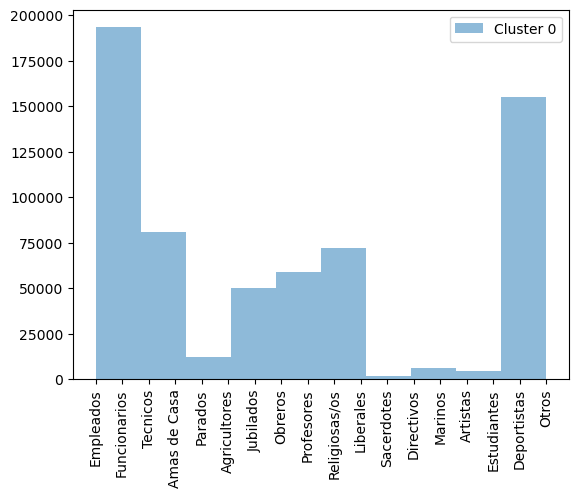

In [162]:
histxvar(spain_2, 'Profesion', rotation='vertical')

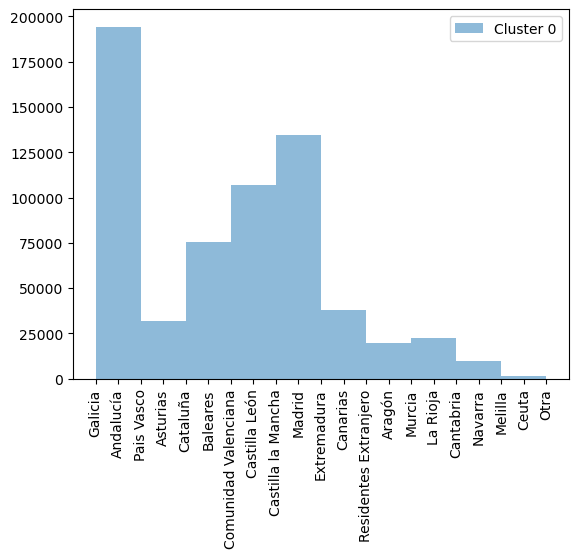

In [164]:
histxvar(spain_2, 'Autonomia', rotation='vertical')

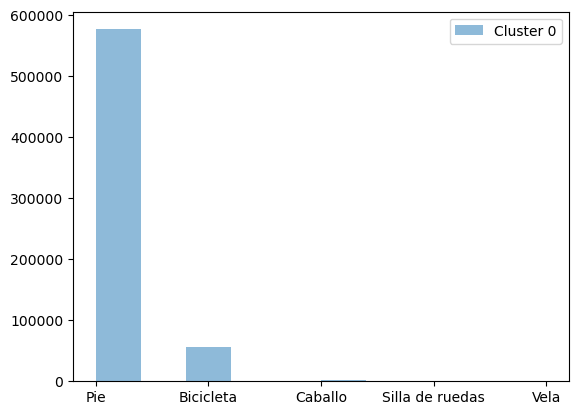

In [170]:
histxvar(spain_2, 'Medio', rotation='horizontal')

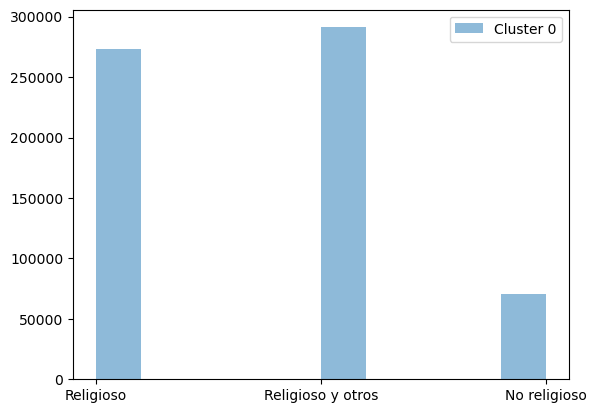

In [171]:
histxvar(spain_2, 'Motivo', rotation='horizontal')

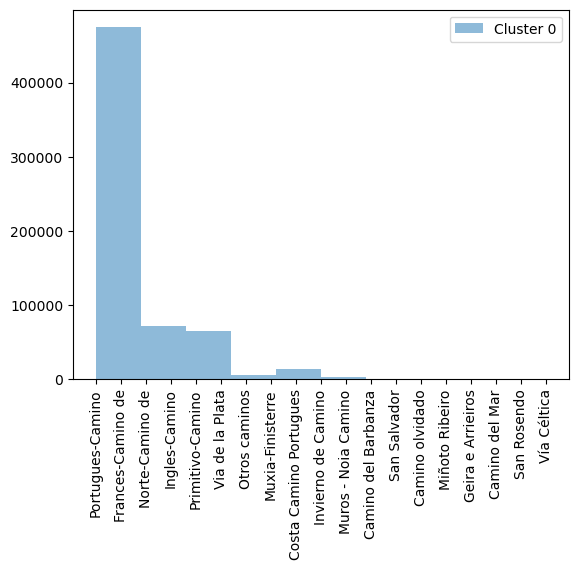

In [173]:
histxvar(spain_2, 'Camino', rotation='vertical')

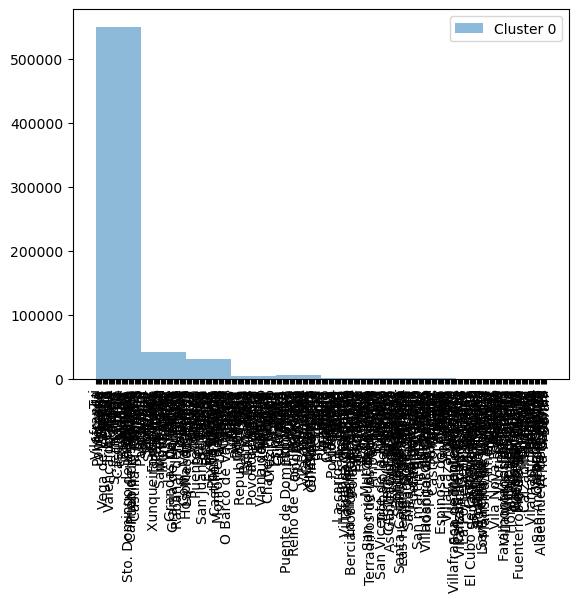

In [174]:
histxvar(spain_2, 'Origen', rotation='vertical')

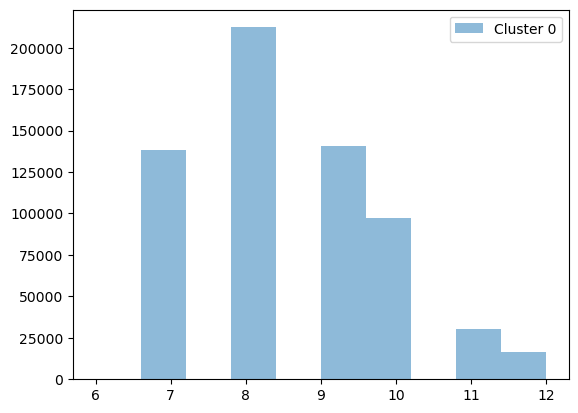

In [163]:
histxvar(spain_2, 'Mes')

## 3. Cluster 1

In [84]:
cluster_1_spain = spain_2.loc[spain_2['Cluster'] == 1]


In [85]:
edad_1 = cluster_1_spain.Edad.mean()
round(edad_1)

46

In [86]:
sexo_1 = cluster_1_spain.Sexo.value_counts().index.tolist()
sexo_1[0]

'M'

In [87]:
autonomia_1 = cluster_1_spain.Autonomia.value_counts().index.tolist()
autonomia_1[0]

'Madrid'

In [88]:
medio_1 = cluster_1_spain.Medio.value_counts().index.tolist()
medio_1[0]

'Pie'

In [89]:
motivo_1 = cluster_1_spain.Motivo.value_counts().index.tolist()
motivo_1[0]

'Religioso y otros'

In [90]:
camino_1 = cluster_1_spain.Camino.value_counts().index.tolist()
camino_1[0]

'Frances-Camino de'

In [91]:
origen_1 = cluster_1_spain.Origen.value_counts().index.tolist()
origen_1[0]

'Sarria'

In [92]:
profesion_1 = cluster_1_spain.Profesion.value_counts().index.tolist()
profesion_1[0]

'Empleados'

In [93]:
mes_1 = cluster_1_spain.Mes.value_counts().index.tolist()
mes_1[:3]

[6, 5, 4]

In [94]:
print("El perfil del Cluster 1 hace referencia a una persona de: \n ",'Edad:',round(edad_1), 'años \n', 'Sexo:',sexo_1[0] , '\n', 'Profesión:', profesion_1[0],'\n', 'Residencia:', autonomia_1[0], '\n', 'Medio de traslado:', medio_1[0], '\n', 'Motivo:', motivo_1[0], '\n', 'Camino realizado:', camino_1[0], '\n', 'Origen:', origen_1[0], '\n', 'Meses más optados:', mes_1[:3])

El perfil del Cluster 1 hace referencia a una persona de: 
  Edad: 46 años 
 Sexo: M 
 Profesión: Empleados 
 Residencia: Madrid 
 Medio de traslado: Pie 
 Motivo: Religioso y otros 
 Camino realizado: Frances-Camino de 
 Origen: Sarria 
 Meses más optados: [6, 5, 4]


In [176]:
def histxvar(df, col, rotation=None):
    plt.hist(df.loc[df['Cluster'] == 1, col], alpha=0.5, label='Cluster 1')
    plt.legend()
    if rotation:
        plt.xticks(rotation=rotation)
    plt.show()

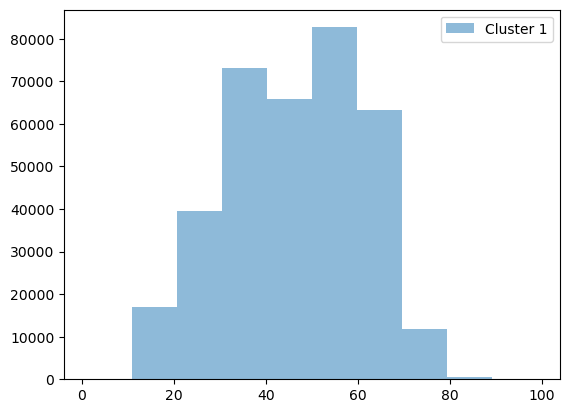

In [177]:
histxvar(spain_2, 'Edad')

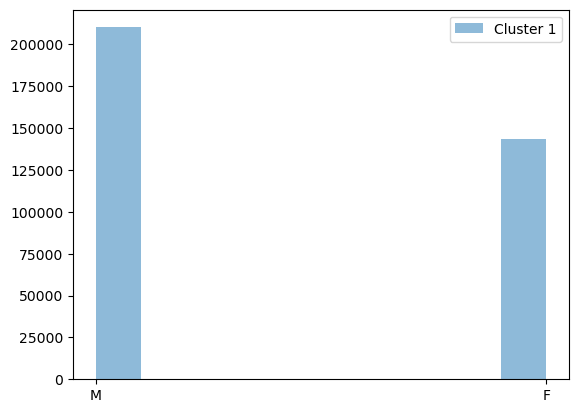

In [178]:
histxvar(spain_2, 'Sexo')

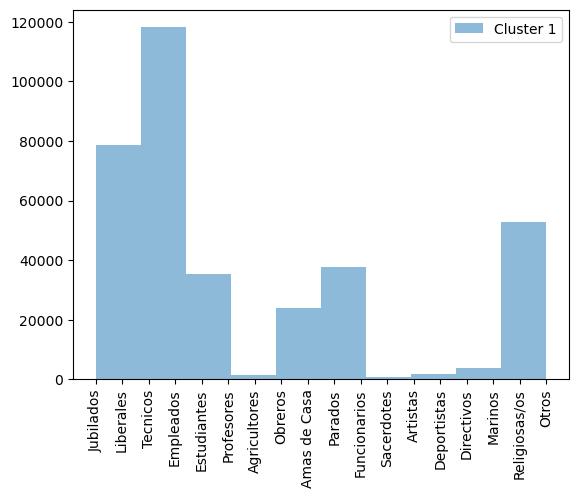

In [181]:
histxvar(spain_2, 'Profesion', rotation = "vertical")

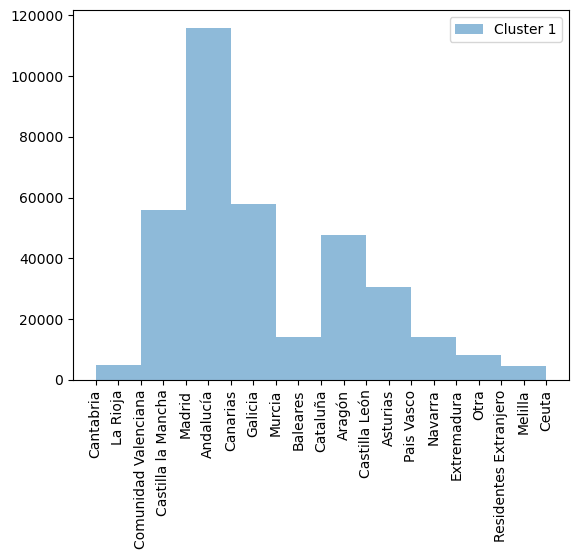

In [186]:
histxvar(spain_2, 'Autonomia', rotation = "vertical")

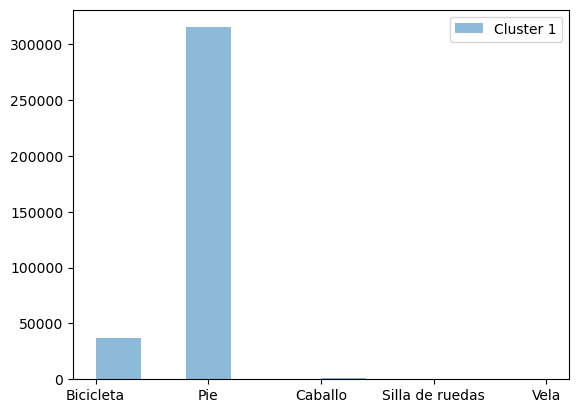

In [185]:
histxvar(spain_2, 'Medio', rotation = "horizontal")

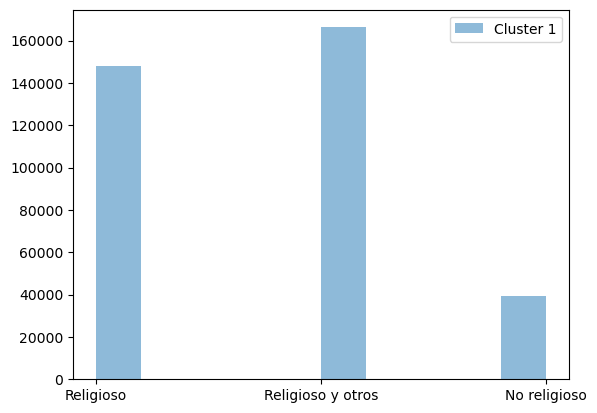

In [187]:
histxvar(spain_2, 'Motivo', rotation = "horizontal")

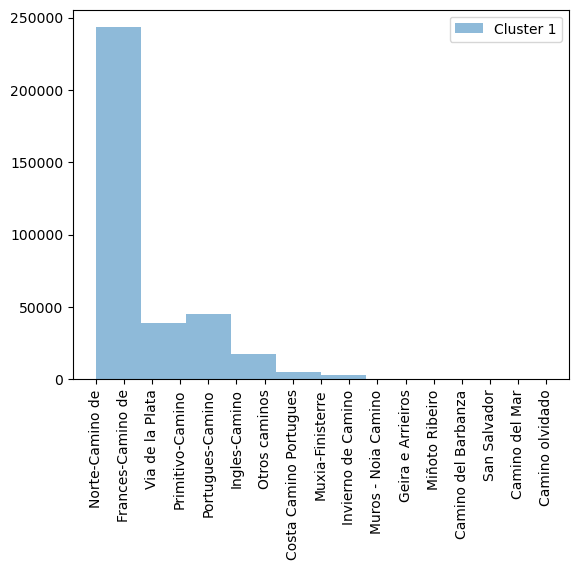

In [191]:
histxvar(spain_2, 'Camino', rotation = "vertical")

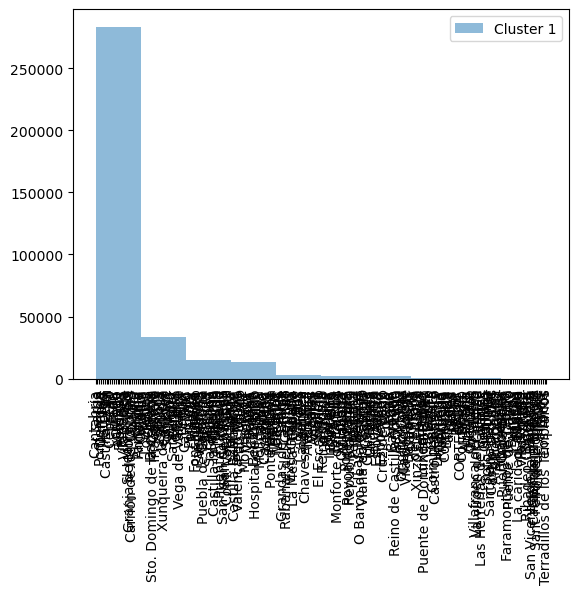

In [189]:
histxvar(spain_2, 'Origen', rotation = "vertical")

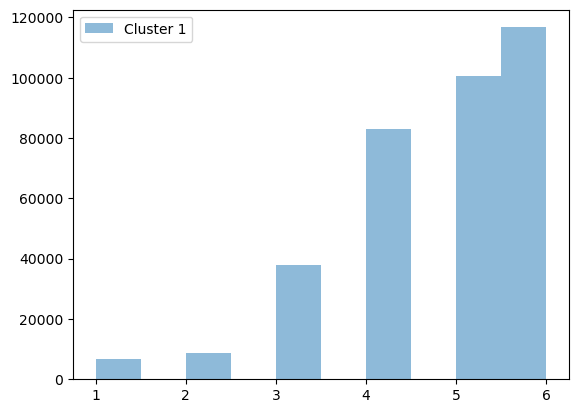

In [192]:
histxvar(spain_2, 'Mes', rotation = "horizontal")

## 4. Cluster 2

In [95]:
cluster_2_spain = spain_2.loc[spain_2['Cluster'] == 2]

In [96]:
edad_2 = cluster_2_spain.Edad.mean()
round(edad_2)

47

In [97]:
sexo_2 = cluster_2_spain.Sexo.value_counts().index.tolist()
sexo_2[0]

'M'

In [98]:
autonomia_2 = cluster_2_spain.Autonomia.value_counts().index.tolist()
autonomia_2[0]

'Cataluña'

In [99]:
medio_2 = cluster_2_spain.Medio.value_counts().index.tolist()
medio_2[0]

'Pie'

In [100]:
motivo_2 = cluster_2_spain.Motivo.value_counts().index.tolist()
motivo_2[0]

'Religioso y otros'

In [101]:
camino_2 = cluster_2_spain.Camino.value_counts().index.tolist()
camino_2[0]

'Frances-Camino de'

In [102]:
origen_2 = cluster_2_spain.Origen.value_counts().index.tolist()
origen_2[0]

'Roncesvalles'

In [103]:
profesion_2 = cluster_2_spain.Profesion.value_counts().index.tolist()
profesion_2[0]

'Empleados'

In [104]:
mes_2 = cluster_2_spain.Mes.value_counts().index.tolist()
mes_2[:3]

[8, 7, 6]

In [105]:
print("El perfil del Cluster 2 hace referencia a una persona de: \n ",'Edad:',round(edad_2), 'años \n', 'Sexo:',sexo_2[0] , '\n', 'Profesión:', profesion_2[0],'\n', 'Residencia:', autonomia_2[0], '\n', 'Medio de traslado:', medio_2[0], '\n', 'Motivo:', motivo_2[0], '\n', 'Camino realizado:', camino_2[0], '\n', 'Origen:', origen_2[0], '\n', 'Mes de viaje:', mes_2[:3])

El perfil del Cluster 2 hace referencia a una persona de: 
  Edad: 47 años 
 Sexo: M 
 Profesión: Empleados 
 Residencia: Cataluña 
 Medio de traslado: Pie 
 Motivo: Religioso y otros 
 Camino realizado: Frances-Camino de 
 Origen: Roncesvalles 
 Mes de viaje: [8, 7, 6]


In [ ]:
histxvar(spain_2, 'Sexo')

## 5. Cluster 3

In [106]:
cluster_3_spain = spain_2.loc[spain_2['Cluster'] == 3]

In [107]:
edad_3 = cluster_3_spain.Edad.mean()
round(edad_3)

22

In [108]:
sexo_3 = cluster_3_spain.Sexo.value_counts().index.tolist()
sexo_3[0]

'F'

In [109]:
autonomia_3 = cluster_3_spain.Autonomia.value_counts().index.tolist()
autonomia_3[0]

'Madrid'

In [110]:
medio_3 = cluster_3_spain.Medio.value_counts().index.tolist()
medio_3[0]

'Pie'

In [111]:
motivo_3 = cluster_3_spain.Motivo.value_counts().index.tolist()
motivo_3[0]

'Religioso'

In [112]:
camino_3 = cluster_3_spain.Camino.value_counts().index.tolist()
camino_3[0]

'Frances-Camino de'

In [113]:
origen_3 = cluster_3_spain.Origen.value_counts().index.tolist()
origen_3[0]

'Sarria'

In [114]:
profesion_3 = cluster_3_spain.Profesion.value_counts().index.tolist()
profesion_3[0]

'Estudiantes'

In [115]:
mes_3 = cluster_3_spain.Mes.value_counts().index.tolist()
mes_3[:3]

[8, 7, 9]

In [116]:
print("El perfil del Cluster 3 hace referencia a una persona de: \n ",'Edad:',round(edad_3), 'años \n', 'Sexo:',sexo_3[0] , '\n', 'Profesión:', profesion_3[0],'\n', 'Residencia:', autonomia_3[0], '\n', 'Medio de traslado:', medio_3[0], '\n', 'Motivo:', motivo_3[0], '\n', 'Camino realizado:', camino_3[0], '\n', 'Origen:', origen_3[0], '\n', 'Mes de viaje:', mes_3[:3])

El perfil del Cluster 3 hace referencia a una persona de: 
  Edad: 22 años 
 Sexo: F 
 Profesión: Estudiantes 
 Residencia: Madrid 
 Medio de traslado: Pie 
 Motivo: Religioso 
 Camino realizado: Frances-Camino de 
 Origen: Sarria 
 Mes de viaje: [8, 7, 9]


## PCA

In [117]:
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler

import seaborn as sns


In [118]:
num_cols = spain.columns.tolist()

In [119]:

# Crear una instancia de PCA y ajustarla a los datos
pca = PCA(n_components=2)
pca.fit(spain)

# Transformar los datos a las nuevas coordenadas del PCA
spain_pca = pd.DataFrame(pca.transform(spain))

exp_var = pca.explained_variance_ratio_       

In [120]:
spain_pca.shape

(1641941, 2)

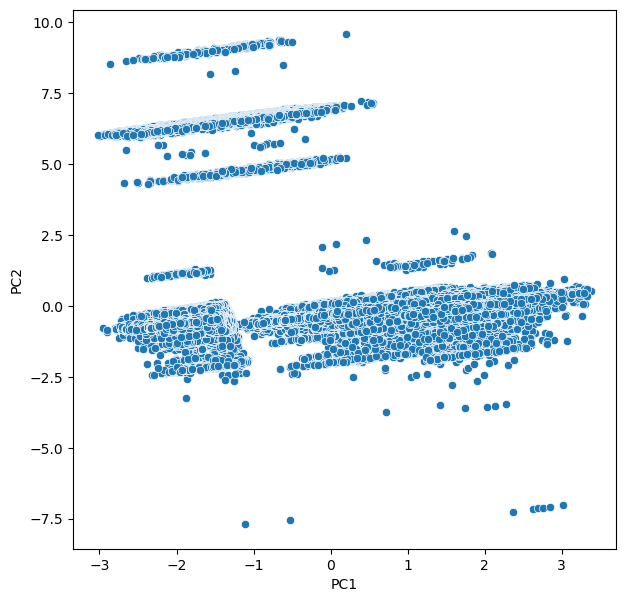

In [121]:

plt.figure(figsize = (7, 7))

sns.scatterplot(x = spain_pca[0], y = spain_pca[1])

plt.xlabel("PC1")

plt.ylabel("PC2")

plt.show()